In [2]:
import pandas as pd
from pathlib import Path
import numpy as np

# ---------- Load ----------
path = Path(r"H:/My Drive/career/proj/sprg/results/all_submissions_pepQuant.csv")
df = pd.read_csv(path)

# ---------- Normalize column names ----------
df.columns = [c.strip() for c in df.columns]

# Helper to find columns by substrings (case-insensitive)
def find_col(candidates):
    lower = {c.lower(): c for c in df.columns}
    for substrs in candidates:
        for lc, orig in lower.items():
            if all(s in lc for s in substrs):
                return orig
    return None

# Required columns (auto-detect common naming)
species_col = find_col([[ "species" ]]) or find_col([[ "organism" ]])
file_col    = find_col([[ "file" ]]) or find_col([[ "filename" ]]) or find_col([[ "run" ]]) or find_col([[ "submission" ]])

a_col = find_col([[ "sample", "a", "quantity" ]]) or find_col([[ "a", "quantity" ]]) or find_col([[ "sample_a" ]])
b_col = find_col([[ "sample", "b", "quantity" ]]) or find_col([[ "b", "quantity" ]]) or find_col([[ "sample_b" ]])
c_col = find_col([[ "sample", "c", "quantity" ]]) or find_col([[ "c", "quantity" ]]) or find_col([[ "sample_c" ]])

missing = [("species", species_col), ("file", file_col), ("A", a_col), ("B", b_col), ("C", c_col)]
missing = [name for name, col in missing if col is None]
if missing:
    raise ValueError(f"Could not auto-detect required columns: {missing}. "
                     f"Available columns: {df.columns.tolist()}")

# ---------- Coerce numeric ----------
for col in [a_col, b_col, c_col]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# ---------- Normalize species labels (DATA-DRIVEN, matches your CSV) ----------
df["species_norm"] = (
    df[species_col]
    .astype(str)
    .str.strip()
    .str.upper()
)

species_map = {
    "HUMAN": "Human",
    "TROUT": "Trout",
    "COW":   "Bovin",
    "BOVIN": "Bovin",
    "BOVINE":"Bovin",
}

df["species_norm"] = df["species_norm"].map(species_map).fillna("Other")

# Site 06, 10, and 41 submitted scaled or transformed data, which need to be converted
submission_type = {
    "06-pepQuant.tsv": "log2",     # already log2
    "41-pepQuant.tsv": "counts",   # count data
    # everything else, including 10 which looks scaled, is raw
}


df["submission_type"] = df[file_col].astype(str).map(submission_type).fillna("raw")

# type-aware x and y
df["x_metric"] = np.nan
df["y_metric"] = np.nan

is_raw    = df["submission_type"] == "raw"
is_log2   = df["submission_type"] == "log2"
is_counts = df["submission_type"] == "counts"

# raw intensities
df.loc[is_raw, "x_metric"] = np.log2(df.loc[is_raw, b_col])
df.loc[is_raw, "y_metric"] = np.log2(df.loc[is_raw, a_col] / df.loc[is_raw, c_col])

# already log2 (06)
df.loc[is_log2, "x_metric"] = df.loc[is_log2, b_col]
df.loc[is_log2, "y_metric"] = df.loc[is_log2, a_col] - df.loc[is_log2, c_col]

# counts (41)
df.loc[is_counts, "x_metric"] = np.log2(df.loc[is_counts, b_col] + 1)
df.loc[is_counts, "y_metric"] = np.log2((df.loc[is_counts, a_col] + 1) / (df.loc[is_counts, c_col] + 1))

df.head()


c:\Users\linds\anaconda3\envs\newenv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\linds\anaconda3\envs\newenv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


,Peptide,Species,Submission,File,Sample A Quantity,Sample B Quantity,Sample C Quantity,Sample B Quantity.1,species_norm,submission_type,x_metric,y_metric
0,AAAAPSSFQLLYDLK,COW,1.0,01-pepQuant.tsv,157.697022,199.811279,563.886780,NaN,Bovin,raw,7.642494,-1.838250
1,AAAAPSSFQLLYDLKLPVEDKIR,COW,1.0,01-pepQuant.tsv,92.983559,137.256561,292.546539,NaN,Bovin,raw,7.100731,-1.653619
2,AAAITSDILETLGR,COW,1.0,01-pepQuant.tsv,87.786659,381.369568,809.646179,NaN,Bovin,raw,8.575046,-3.205218
3,AAANMDLM,COW,1.0,01-pepQuant.tsv,128.475571,304.646393,626.192932,NaN,Bovin,raw,8.250992,-2.285113
4,AAAYNLVQR,COW,1.0,01-pepQuant.tsv,251.163925,509.693909,1075.693848,NaN,Bovin,raw,8.993487,-2.098566


In [ ]:
import numpy as np

mix = {
    "A": {"Trout": 50, "Human": 45, "Bovin": 5},
    "B": {"Trout": 50, "Human": 20, "Bovin": 30},
    "C": {"Trout": 50, "Human": 3,  "Bovin": 47},
}

def expected_log2_ratio(numer, denom):
    out = {}
    for sp in ["Trout", "Human", "Bovin"]:
        out[sp] = np.log2(mix[numer][sp] / mix[denom][sp])
    return out

expected_ac = expected_log2_ratio("A", "C")  # for y = log2(A/C)
expected_ab = expected_log2_ratio("A", "B")
expected_bc = expected_log2_ratio("B", "C")

expected_ac

{'Trout': np.float64(0.0),
 'Human': np.float64(3.9068905956085187),
 'Bovin': np.float64(-3.232660756790275)}

c:\Users\linds\anaconda3\envs\newenv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\linds\anaconda3\envs\newenv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


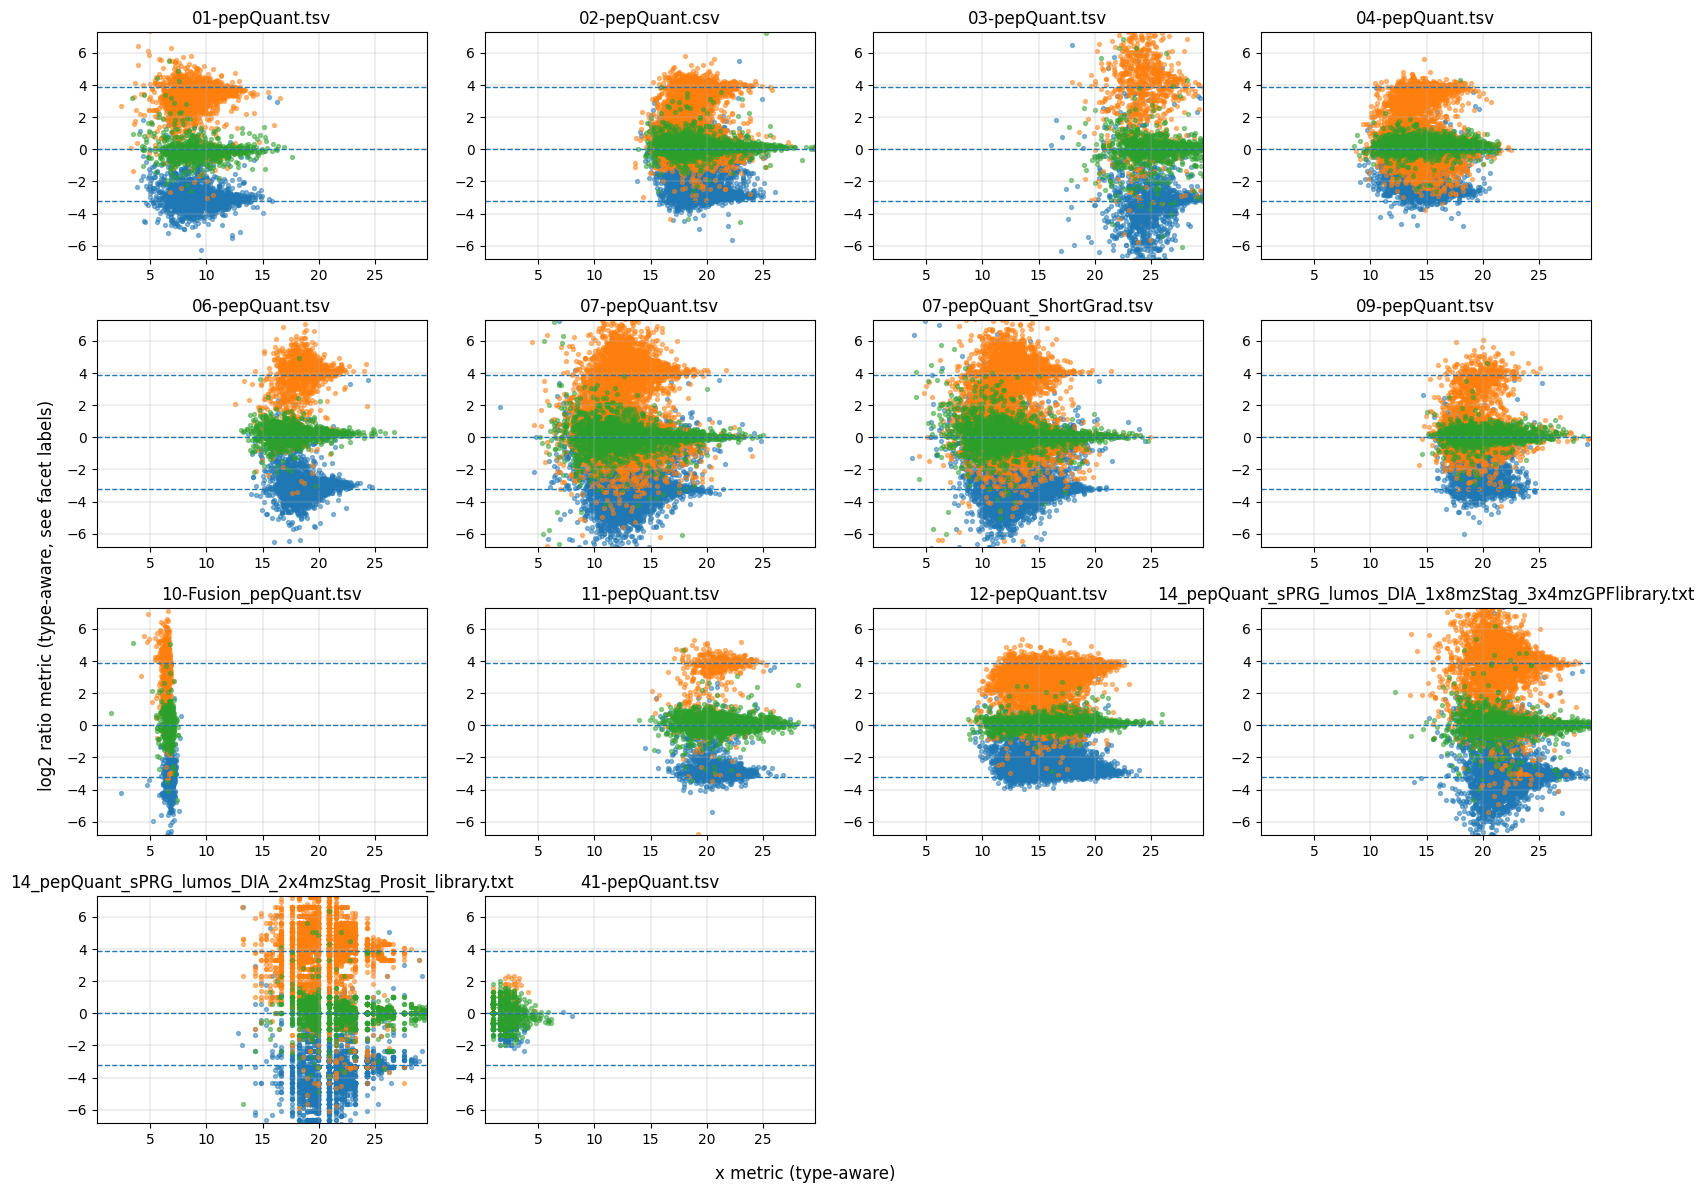

In [4]:
import numpy as np
import matplotlib.pyplot as plt

df["log2_ratio_metric"] = np.nan
df["ratio_metric_note"] = ""

is_raw    = df["submission_type"] == "raw"
is_log2   = df["submission_type"] == "log2"
is_scaled = df["submission_type"] == "scaled"
is_counts = df["submission_type"] == "counts"

# raw intensities
df.loc[is_raw, "log2_ratio_metric"] = np.log2(df.loc[is_raw, a_col] / df.loc[is_raw, c_col])
df.loc[is_raw, "ratio_metric_note"] = "log2(A/C) from raw"

# log2 submissions
df.loc[is_log2, "log2_ratio_metric"] = df.loc[is_log2, a_col] - df.loc[is_log2, c_col]
df.loc[is_log2, "ratio_metric_note"] = "A−C (input already log2)"

# count submissions
df.loc[is_counts, "log2_ratio_metric"] = np.log2((df.loc[is_counts, a_col] + 1) / (df.loc[is_counts, c_col] + 1))
df.loc[is_counts, "ratio_metric_note"] = "log2((A+1)/(C+1)) counts, not comparable"

# build x axis too, with type-aware logic
df["x_metric"] = np.nan
df.loc[is_raw, "x_metric"] = np.log2(df.loc[is_raw, b_col])
df.loc[is_log2 | is_scaled, "x_metric"] = df.loc[is_log2 | is_scaled, b_col]  # assume already log-like
df.loc[is_counts, "x_metric"] = np.log2(df.loc[is_counts, b_col] + 1)

# prepare dataframe for plotting
plot_df_all = df.loc[
    (df[a_col] > 0) & (df[b_col] > 0) & (df[c_col] > 0) &
    (df["species_norm"].isin(["Human", "Bovin", "Trout"]))
].copy()

# drop blank files (<= 1 row)
counts = plot_df_all.groupby(file_col).size()
keep_files = counts[counts > 1].index.astype(str)
plot_df_all = plot_df_all[plot_df_all[file_col].astype(str).isin(keep_files)].copy()

# global axis limits
x_min, x_max = np.nanpercentile(plot_df_all["x_metric"], [0.5, 99.5])
y_min, y_max = np.nanpercentile(plot_df_all["log2_ratio_metric"], [0.5, 99.5])
padx, pady = 0.05*(x_max-x_min), 0.05*(y_max-y_min)
x_lim = (x_min-padx, x_max+padx)
y_lim = (y_min-pady, y_max+pady)

files = sorted(plot_df_all[file_col].dropna().astype(str).unique())
n = len(files)
ncol = 4
nrow = int(np.ceil(n / ncol))

fig, axes = plt.subplots(nrow, ncol, figsize=(4*ncol, 3*nrow), squeeze=False)

species_order = ["Bovin", "Human", "Trout"]

for i, fname in enumerate(files):
    r, c = divmod(i, ncol)
    ax = axes[r, c]
    sub = plot_df_all[plot_df_all[file_col].astype(str) == fname]

    # points
    for sp in species_order:
        ss = sub[sub["species_norm"] == sp]
        if ss.empty:
            continue
        ax.scatter(ss["x_metric"], ss["y_metric"], s=8, alpha=0.5)

        # expected log2(A/C) horizontal line for that species
        ax.axhline(expected_ac[sp], linestyle="--", linewidth=1)

    ax.set_title(fname)
    ax.set_xlim(*x_lim)
    ax.set_ylim(*y_lim)
    ax.grid(True, linewidth=0.3)


for j in range(n, nrow*ncol):
    r, c = divmod(j, ncol)
    axes[r, c].axis("off")

fig.supxlabel("x metric (type-aware)")
fig.supylabel("log2 ratio metric (type-aware, see facet labels)")
plt.tight_layout()
plt.show()


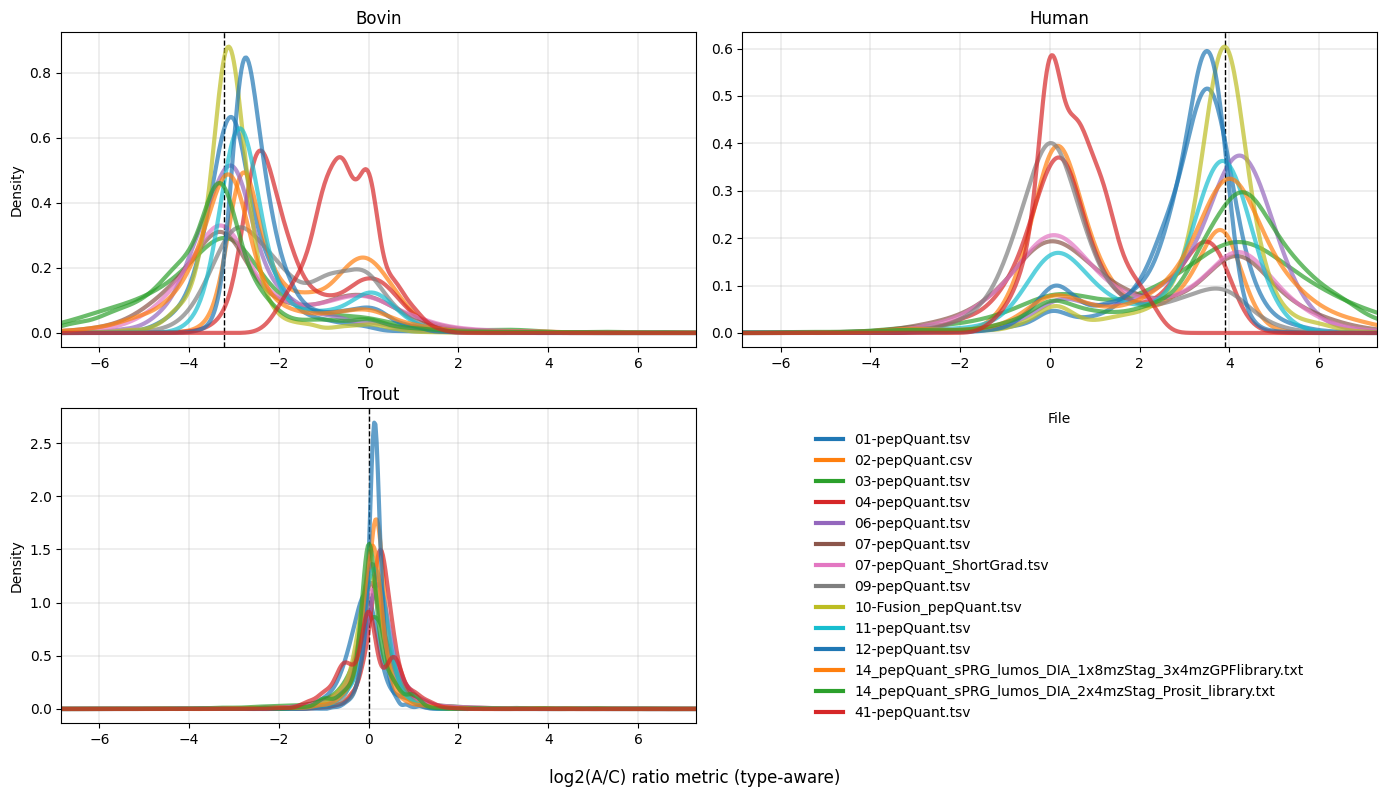

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from matplotlib.lines import Line2D

# uses your existing: mix, expected_log2_ratio(), expected_ac

value_col = "y_metric"          # <-- key change
min_points_per_curve = 50

# robust x-range for density grid
vals_all = plot_df_all[value_col].replace([np.inf, -np.inf], np.nan).dropna().values
x_min, x_max = np.nanpercentile(vals_all, [0.5, 99.5])
pad = 0.05 * (x_max - x_min) if x_max > x_min else 1.0
x_lim = (x_min - pad, x_max + pad)
grid = np.linspace(x_lim[0], x_lim[1], 512)

species_panels = ["Bovin", "Human", "Trout"]
files = sorted(plot_df_all[file_col].dropna().astype(str).unique())

fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1], width_ratios=[1, 1])

ax_bovin = fig.add_subplot(gs[0, 0])
ax_human = fig.add_subplot(gs[0, 1])
ax_trout = fig.add_subplot(gs[1, 0])
ax_leg   = fig.add_subplot(gs[1, 1])

axes_map = {"Bovin": ax_bovin, "Human": ax_human, "Trout": ax_trout}

legend_handles = []

for sp, ax in axes_map.items():
    sub_sp = plot_df_all[plot_df_all["species_norm"] == sp]

    # expected reference line (A/C)
    ax.axvline(expected_ac[sp], linestyle="--", linewidth=1, color="black")

    for fname in files:
        sub = sub_sp[sub_sp[file_col].astype(str) == fname]
        vals = sub[value_col].replace([np.inf, -np.inf], np.nan).dropna().values
        if len(vals) < min_points_per_curve:
            continue

        kde = gaussian_kde(vals)
        dens = kde(grid)
        line, = ax.plot(grid, dens, linewidth=3, alpha=0.7)

        # legend entries (one per file)
        if sp == "Bovin":
            legend_handles.append(Line2D([0], [0], color=line.get_color(), lw=3, label=fname))

    ax.set_title(sp)
    ax.set_xlim(*x_lim)
    ax.grid(True, linewidth=0.3)

ax_bovin.set_ylabel("Density")
ax_trout.set_ylabel("Density")
fig.supxlabel("log2(A/C) ratio metric (type-aware)")

ax_leg.axis("off")
ax_leg.legend(handles=legend_handles, title="File", loc="center", frameon=False, ncol=1)

plt.tight_layout()
plt.show()
